In [547]:
import math
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

import ot
from ot import dist, emd2

import autograd.numpy as np
from autograd import grad

import torch

# Experiment 1: 1D Gaussian dynamics

$$x_{t+1} = f(x_t) + \epsilon_t, \; \epsilon_t \sim \mathcal{N}(0, \sigma^{2}_\epsilon)$$

In this first experiment, our dynamics is given by $f(x) = \phi(x)$, where $\phi(x)$ is the function describing the Gaussian density with mean $0$ and variance $1$. This dynamics takes states far from zero and bring back to zero, while states close to zero are taken to positions close to $0.4$. Thus, for any initial distribution, as time goes on, the state distribution tends to get more concentrated close to zero.

We consider an initial distribution $\mathbb{P}_{0} = \mathcal{N}(1, \sigma^{2}_0)$, which is centered in the region where the dynamics $f$ has the highest variation.

### 1) Define dynamics

We define $f(x)$ and compute its global Lipschitz constant.

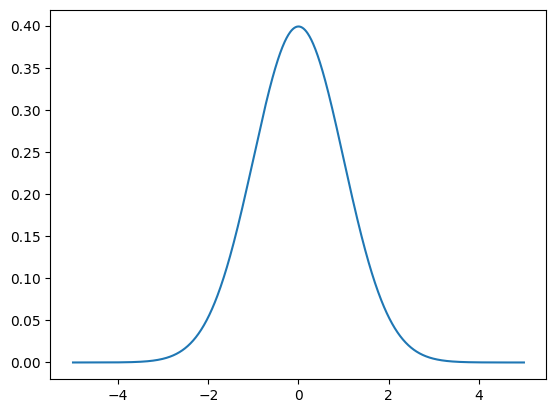

In [548]:
mu, sigma = 0, 1
def f(x):
    coefficient = 1 / (sigma * math.sqrt(2 * math.pi))
    exponent = math.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return coefficient * exponent
    
def global_lipsc():
    return np.exp(-1/2)/2*np.pi

#Plot dynamics
x_data = np.linspace(-5, 5, 1000)
dynamics = [f(x) for x in x_data]
plt.plot(x_data, dynamics)

In [549]:
#Global Lipschitz constant of f
global_lipsc()

0.9527361323650899

### 2) System assumptions

##### 2.1) Noise structure

We consider, for every $t$, the noise structure to be given by $\epsilon_t \sim \mathcal{N}(0, \sigma^{2}_\epsilon)$, with $\sigma^{2}_\epsilon = 0.3^2$.

In [550]:
n_samples = 1000

mean_noise = 0
std_dev_noise = 0.3
noise_samples = norm.rvs(loc = mean_noise, scale = std_dev_noise, size = n_samples)

##### 2.2) Initial distribution

We consider $\mathbb{P}_{0} = \mathcal{N}(1, \sigma^{2}_0)$.

In [551]:
mean_initial = 1
std_dev_initial = 2.5

initial_distribution_samples = norm.rvs(loc = mean_initial, scale = std_dev_initial, size = n_samples)

##### 2.3) Monte Carlo simulation of the system

We sample the system and build the histograms for $x_0$ and $x_1$. Those are approximations of the true distributions $\mathbb{P}_0$ and $\mathbb{P}_1$.

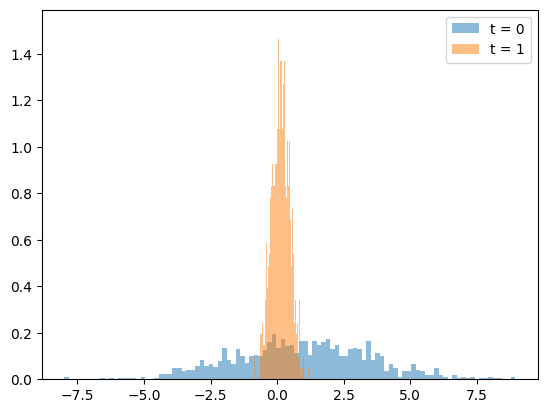

In [552]:
propagated_states = np.array([f(x) + noise_samples[i] for i, x in enumerate(initial_distribution_samples)])

plt.hist(initial_distribution_samples, alpha=0.5, label='t = 0', bins=100, density=True)
plt.hist(propagated_states, alpha=0.5, label='t = 1', bins=100, density=True)
plt.legend()

### 3) Create signature approximation for $\mathbb{P}_0$

We create a naive signature approximation for $\mathbb{P}_0 \sim \mathcal{N}(\mu_0, \sigma^{2}_{0})$ by taking N-1 equally spaced points between $[\mu_0 - 3\sigma_0, \mu_0 + 3\sigma_0]$. Then we create $N$ regions forming a partition of $\mathbb{R}$ in which each signature is in its center location (except for the unbounded regions, where the signatures are in arbitrary pre-chosen locations). 

<BarContainer object of 10 artists>

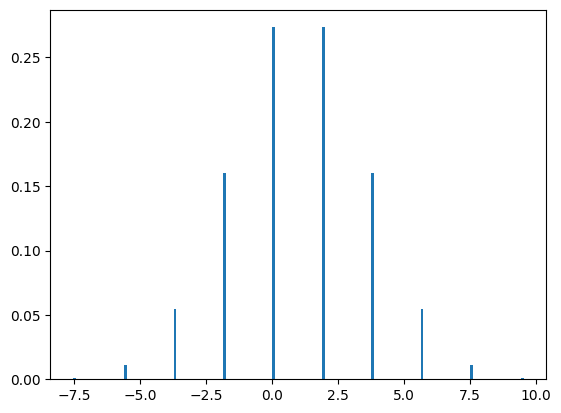

In [553]:
n_signatures = 9

#Create signaturization for initial distribution
points = [-np.inf]
points.extend(list(np.linspace(mean_initial - 3*std_dev_initial, mean_initial + 3*std_dev_initial, n_signatures)))
points.append(np.inf)

initial_signature_probas = [norm.cdf(points[i], loc = mean_initial, scale = std_dev_initial) - norm.cdf(points[i-1], loc = mean_initial, scale = std_dev_initial) for i in range(1, len(points))]

signatures = []
for i in range(1, len(points)):
    if i == 1:
        signatures.append(mean_initial - 3*std_dev_initial - 1)
    elif i == len(points)-1:
        signatures.append(mean_initial + 3*std_dev_initial + 1)
    else:
        signatures.append(points[i-1] + (points[i] - points[i-1])/2)

plt.bar(signatures, initial_signature_probas, width=0.1)

##### 3.1) Transform signatures and probability array in Tensors

In [554]:
signatures = torch.tensor(signatures)
initial_signature_probas = torch.tensor(initial_signature_probas)

#We also convert the arrays related to the true distribution
initial_distribution_samples = torch.tensor(initial_distribution_samples)

In [555]:
#Check probas
initial_signature_probas.sum()

tensor(1., dtype=torch.float64)

##### 3.2) Compute $\mathbb{W}_{2}(\mathbb{P}_0, \Delta \# \hat{\mathbb{P}}_0)$

We compute an approximation of this quantity by sampling from $\mathbb{P}_0$ and using the POT package.

In [556]:
# Define uniform weights for the samples (assuming they are empirical samples)
sample_weights = torch.ones(initial_distribution_samples.size(0)) / initial_distribution_samples.size(0)

In [557]:
# Compute the cost matrix (squared Euclidean distance between points)
M = ot.dist(signatures.reshape((len(signatures), 1)), initial_distribution_samples.reshape((len(initial_distribution_samples), 1)), metric = 'sqeuclidean')

wasserstein_squared_zero = ot.emd2(initial_signature_probas, sample_weights, M)

#2-W distance between the true P_0 and our signature approximation
wasserstein_squared_zero ** 0.5

tensor(0.5424, dtype=torch.float64)

##### 3.3) Compute $\mathbb{W}_{2}(\mathbb{P}_1, \hat{\mathbb{P}}_1)$

Recall that although $\mathbb{P}_1$ is unknown, we can generate samples via MC simulation. Additionally, in our setting, $\hat{\mathbb{P}}_1$ is a GMM with $N$ components centered at $f(x^{\text{signature}}_{i})$ with variance $\sigma^{2}_{\epsilon}$. We sample from this GMM and compute the Wasserstein distance between those two samples to obtain an approximation of the actual Wasserstein distance between the true $\mathbb{P}_1$ and our GMM.

In [558]:
def sample_gmm(centers, probabilities, st_dev, n_samples=1):
    
    #Choose a component based on the provided probabilities
    chosen_components = np.random.choice(len(centers), size = n_samples, p = probabilities)
    
    #Sample from the chosen Gaussian component
    samples = np.array([np.random.normal(centers[i], st_dev) for i in chosen_components])
    
    return samples

In [559]:
centers = torch.Tensor([f(signature) for signature in signatures])
samples_gmm = sample_gmm(centers, initial_signature_probas, std_dev_noise, n_samples=1000)

In [560]:
# Compute the cost matrix (squared Euclidean distance between samples)
M = ot.dist(samples_gmm.reshape((len(samples_gmm), 1)), propagated_states.reshape((len(propagated_states), 1)), metric = 'sqeuclidean')

# Compute the squared Wasserstein distance
wasserstein_squared_propagation = ot.emd2([], [], M)

wasserstein_squared_propagation ** 0.5

0.024764155742395953

**Remark**: As previously mentioned, the dynamics tends to concentrate the mass around zero. Therefore, although $\mathbb{W}_{2}(\mathbb{P}_0, \Delta \# \hat{\mathbb{P}}_0)$ is reasonably big, we see that $\mathbb{W}_{2}(\mathbb{P}_1, \hat{\mathbb{P}}_1)$ is actually very small.

It is clear that propagating the uncertainty with the global Lipschitz is considerably bad in this case.

### 4) Propagating with global Lipschitz

In [561]:
(global_lipsc()**2 * wasserstein_squared_zero) ** 0.5

tensor(0.5167, dtype=torch.float64)

### 5) Propagating with our method

##### 5.1) Create regions

In [562]:
def build_regions(states):

    n = states.size(0)
    regions = []

    for i in range(n):
        if i == 0:
            #First region
            left_bound = -float('inf')
            right_bound = states[i] + (states[i+1] - states[i]) / 2
        elif i == n - 1:
            #Last region
            left_bound = states[i] - (states[i] - states[i-1]) / 2
            right_bound = float('inf')
        else:
            #Middle regions
            left_bound = states[i] - (states[i] - states[i-1]) / 2
            right_bound = states[i] + (states[i+1] - states[i]) / 2
        
        regions.append(torch.tensor([left_bound, right_bound]))

    # Stack the regions into a single tensor
    return torch.stack(regions)

In [563]:
regions = build_regions(signatures)
regions

tensor([[   -inf, -6.5312],
        [-6.5312, -4.6250],
        [-4.6250, -2.7500],
        [-2.7500, -0.8750],
        [-0.8750,  1.0000],
        [ 1.0000,  2.8750],
        [ 2.8750,  4.7500],
        [ 4.7500,  6.6250],
        [ 6.6250,  8.5312],
        [ 8.5312,     inf]], dtype=torch.float64)

##### 5.2) Compute interval approximations for $f$

Given two regions $\mathcal{R}_1, \mathcal{R}_2$, we return a $\beta$ such that $|f(x_1) - f(x_2)|^2 \leq \beta$ for any $x_1 \in \mathcal{R}_1$, $x_2 \in \mathcal{R}_2$. Note that this works for $\mathcal{R}_\text{unbounded}$ as $f$ is a bounded function.

<span style="color: red;">TODO</span>: This function is currently wrong when the region contains the point $0$, but it is a very good proxy. This will be addressed later.

In [564]:
def interval_approximation(region_1, region_2):

    a_0, b_0 = region_1[0], region_1[1]
    a_1, b_1 = region_2[0], region_2[1]

    max_value = 0

    max_value = max(max_value, abs(f(a_0) - f(a_1)))
    max_value = max(max_value, abs(f(a_0) - f(b_1)))
    max_value = max(max_value, abs(f(b_0) - f(a_1)))
    max_value = max(max_value, abs(f(b_0) - f(b_1)))

    return max_value

In [565]:
beta = np.zeros((len(regions), len(regions)))

for i in range(len(regions)):
    for j in range(len(regions)):
        
        interval_approx = interval_approximation(regions[i], regions[j])

        beta[i][j] = interval_approx ** 2

beta = torch.Tensor(beta)
#beta

##### 5.3) Compute projection matrix

This element $(i, j)$ of this matrix contains the quantity $|\text{proj}_{\mathcal{R}_i}(c_j) - c_j|^2$.

<span style="color: red;">TODO</span>: This function can be vectorized. We address this later as we only compute this matrix once.

In [566]:
projection_matrix = np.zeros((len(regions), len(regions)))

for i in range(len(regions)):
    for j in range(len(regions)):

        project = 0
        if(signatures[j] <= regions[i][0]):
            project = regions[i][0] - signatures[j]
        elif(signatures[j] >= regions[i][1]):
            project = signatures[j] - regions[i][1]

        projection_matrix[i][j] = project ** 2

projection_matrix = torch.Tensor(projection_matrix)
#projection_matrix

##### 5.4) Compute constant term

This term is equivalent to the $a_{k \ell}(\omega)$ term before Proposition 10.

In [567]:
def compute_constant_term(k, l, omega, signature_probas, beta):

    omega_k = omega[k]
    omega_l = omega[l]
    
    value = torch.sum(omega_k * signature_probas * beta[k] * (2 - omega_l))
    
    return value


##### 5.5) Project matrix on subspace

Our matrix $\Omega$ needs to satisfy $\sum_{j} \omega_{ij} \hat{p}_j = 1$. Given a matrix $\Omega^{'}$ that may disrespect this restriction, we enforce it by making the following adjustment (denote by $\hat{p}$ the vector with all $\hat{p}_j$):

$$
\Omega^{'} \leftarrow \Omega^{'} + \frac{\mathbb{1} - \Omega^{'} v}{v^T v} v^T
$$

In [568]:
def projection_on_subspace(omega, proba_vector):
    
    if omega.dim() == 1:
        omega = omega.unsqueeze(0)

    if omega.dtype != proba_vector.dtype:
        # Convert both tensors to float32 if their types don't match
        omega = omega.to(torch.float32)
        proba_vector = proba_vector.to(torch.float32)

    ones = torch.ones(omega.size(0), dtype=torch.float32)
    factor = torch.dot(proba_vector, proba_vector)
    omega_dot_proba = torch.matmul(omega, proba_vector)
    c = (ones - omega_dot_proba) / factor

    projection = omega + (c.unsqueeze(1) * proba_vector.unsqueeze(0))
    
    return projection

##### 5.6) Compute bound using method


<span style="color: red;">TODO</span>: Re-check code after vectorization.

In [569]:
def compute_bound(lambd, omega, signature_probas, beta, projection_matrix, budget):
    
    num_regions = len(signature_probas)

    #Create an empty tensor to store the max values for each pair (i, j)
    max_values = torch.full((num_regions, num_regions), -float('inf'), device = omega.device)

    for k in range(num_regions):
        for l in range(num_regions):
            #Compute the matrix of compute_a(k, l, omega) values in a vectorized way
            a_kl = compute_constant_term(k, l, omega, signature_probas, beta)

            #Compute the value matrix for all (i, j) pairs
            value_matrix = a_kl - lambd * (projection_matrix[k][:, None] + projection_matrix[l])

            #Get the element-wise maximum between the current value matrix and max_values
            max_values = torch.maximum(max_values, value_matrix)

    #Compute the outer_sum with broadcasting and vectorized operations
    outer_sum = torch.sum(signature_probas[:, None] * signature_probas[None, :] * max_values)
    
    outer_sum += lambd * 2 * budget

    return torch.sqrt(outer_sum)


def compute_gradients(lambd, omega, signature_probas, beta, projection_matrix, budget):

    #Forward pass
    result = compute_bound(lambd, omega, signature_probas, beta, projection_matrix, budget)
    
    #Backward pass to compute gradients
    result.backward()

    # Gradients
    lambda_grad = lambd.grad
    omega_grad = omega.grad

    return lambda_grad, omega_grad

##### 5.7) Project $\Omega$ to $M_{+}$

To ensure that we only have positive values in $\Omega$, what we currently do is: in each step of the gradient descent, we check whether this is true. If not, we replace the negative value for a random value between $0$ and $0.1$.

<span style="color: red;">TODO 1</span>: WE ARE NOT USING THIS IN THE GRADIENT DESCENT. OUR METHOD IS CURRENTLY ALLOWING FOR NEGATIVE TERMS. WE NEED TO FIX THIS.


<span style="color: red;">TODO 2</span>: Steven gave the idea of optimizing for the squared values.

In [570]:
def has_negative_value(matrix):
    return (matrix < 0).any()

def replace_negative_with_random_value(matrix, low=0.0, high=0.1):

    matrix = matrix.to(torch.double)
    
    mask = matrix < 0
    random_positive_values = low + (high - low) * torch.rand_like(matrix)
    
    # Create a new tensor to hold the result (to avoid in-place operations)
    result = torch.where(mask, random_positive_values, matrix)
    
    return torch.Tensor(result)

##### 5.8) Gradient descent

In [571]:
def gradient_descent(
    lambd,
    omega,
    signature_probas,
    beta,
    projection_matrix,
    budget,
    lr=0.001,  # Learning rate
    num_iterations=100,  # Number of iterations
    epsilon=1e-8  # Tolerance for early stopping
):
    # Initialize the Adam optimizer
    optimizer = torch.optim.Adam([lambd, omega], lr = lr)

    # Store losses for tracking the optimization progress
    loss_history = []

    for iteration in range(num_iterations):
        optimizer.zero_grad()  # Reset gradients to zero before backpropagation

        # Perform the forward and backward passes to compute the gradients
        result = compute_bound(lambd, omega, signature_probas, beta, projection_matrix, budget)
        result.backward()

        # Perform an optimization step (gradient descent step)
        optimizer.step()

        #if(has_negative_value(omega)):
        #    omega = replace_negative_with_random_value(omega)
        #    omega = projection_on_subspace(omega, signature_probas)

        # Optionally track the loss (objective function value)
        loss_history.append(result.item())

        # Optional: Print progress
        if iteration % 10 == 0:
            print(f"Iteration {iteration}/{num_iterations}, Bound: {result.item()}")

        # Check for convergence (early stopping)
        if len(loss_history) > 1 and abs(loss_history[-1] - loss_history[-2]) < epsilon:
            print("Converged after {} iterations.".format(iteration))
            break

    return lambd, omega, loss_history

In [572]:
#lambda_param = 0.1
#omega = np.ones((len(regions), len(regions)))

lambd = torch.tensor(0.1, requires_grad = True)
omega = torch.rand(len(regions), len(regions), requires_grad = True)

In [573]:
# Perform gradient descent using Adam
optimized_lambda, optimized_omega, losses = gradient_descent(
    lambd = lambd,
    omega = omega,
    signature_probas = initial_signature_probas,
    beta = beta,
    projection_matrix = projection_matrix,
    budget = wasserstein_squared_zero,
    lr = 0.001,
    num_iterations = 450
)

Iteration 0/450, Bound: 0.32077974536296966
Iteration 10/450, Bound: 0.31040139056447485
Iteration 20/450, Bound: 0.29958484652493944
Iteration 30/450, Bound: 0.2882202941278712
Iteration 40/450, Bound: 0.27618505446326963
Iteration 50/450, Bound: 0.26333549945510853
Iteration 60/450, Bound: 0.24949102576038729
Iteration 70/450, Bound: 0.23440831225681982
Iteration 80/450, Bound: 0.2194574604396092
Iteration 90/450, Bound: 0.2124142136570983
Iteration 100/450, Bound: 0.20971308742662176
Iteration 110/450, Bound: 0.20590608206134947
Iteration 120/450, Bound: 0.2031523993026961
Iteration 130/450, Bound: 0.20036774660134157
Iteration 140/450, Bound: 0.19800494321924106
Iteration 150/450, Bound: 0.1957442626448099
Iteration 160/450, Bound: 0.1934596699071563
Iteration 170/450, Bound: 0.19115853614092163
Iteration 180/450, Bound: 0.18882413982235746
Iteration 190/450, Bound: 0.18645941654948933
Iteration 200/450, Bound: 0.18403288337615753
Iteration 210/450, Bound: 0.18157969402891186
Itera

In [574]:
omega = projection_on_subspace(omega, initial_signature_probas)
omega

tensor([[ 0.9175,  0.6907,  1.1856,  0.9367,  1.0203,  0.5143,  1.7921,  1.0449,
          1.1656,  0.8738],
        [ 0.2897,  0.5350,  0.5414,  0.5953,  1.1896,  0.8541,  1.5794,  0.8199,
          1.1009,  0.9565],
        [ 0.3515,  0.7971,  0.3075,  0.8070,  1.3194,  0.8802,  1.1012,  0.9906,
          1.2303,  0.2521],
        [-0.2152,  0.5427,  0.2419,  1.0751,  1.1304,  1.2195,  1.0277,  0.0426,
         -0.0035,  0.3332],
        [-0.4176,  0.1632, -0.2237,  0.9309,  1.5313,  0.9472,  1.1009,  0.0820,
          0.4501, -0.4881],
        [ 0.1211,  0.5651,  0.3416,  0.6875,  1.5292,  0.9162,  0.9728,  0.6436,
          0.5218,  0.2816],
        [ 0.5336,  1.1736,  0.9228,  0.8590,  1.1063,  0.7569,  1.4134,  1.0241,
          0.6400,  0.5680],
        [ 0.8371,  0.5728,  0.4264,  0.3245,  0.7094,  1.2717,  1.8234,  1.3272,
          0.9782,  1.0480],
        [ 0.4267,  0.7569,  1.0602,  0.3022,  0.6448,  1.2473,  1.9325,  0.9521,
          0.5476,  0.7396],
        [ 1.0865,  